In [228]:
import pandas as pd
import numpy as np
from skimpy import clean_columns
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from datetime import datetime
import scipy.stats as stats
import scikit_posthocs as sp

# from datetime import timedelta


## Wire Mesh Data

In [229]:
# Read 2023 wire mesh data.

wm_2023 = pd.read_csv("Data/2023_wire_mesh_clean.csv")
wm_2023["total_scm"] = wm_2023["scm_larvae_sum"] + wm_2023["scm_pupae_sum"]
wm_2023.head()


,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm
0,POV_DUN,4/18/23,Corn,10.0,0,0,0,0
1,POV_DUN,4/18/23,Bean,11.0,1,0,1,1
2,DIP_CUR,4/18/23,Bean,5.0,0,17,0,17
3,DIP_CUR,4/18/23,Corn,9.0,0,0,0,0
4,DIP_PAT,4/18/23,Corn,10.0,0,0,0,0


In [230]:
# Read 2024 wire mesh data.

wm_2024 = pd.read_csv("Data/2024_wire_mesh_clean.csv")
wm_2024["total_scm"] = wm_2024["scm_larvae_sum"] + wm_2024["scm_pupae_sum"]
wm_2024


,field_id,collection_date,number_seeds,scm_seeds,seed_type,scm_larvae_sum,scm_pupae_sum,total_scm
0,DEG_DIE_HILL,4/15/24,10,0,lima,0,0,0
1,DEG_DIE_HILL,4/15/24,10,0,corn,0,0,0
2,DEG_DIE_HILL,4/15/24,10,0,soy,0,0,0
3,DEG_DIE_HILL,4/29/24,10,0,corn,0,0,0
4,DEG_DIE_HILL,4/15/24,10,0,lima,0,0,0
...,...,...,...,...,...,...,...,...
614,ZUE_REE,5/21/24,10,0,soy,0,0,0
615,ZUE_REE,5/21/24,9,0,soy,0,0,0
616,ZUE_REE,5/21/24,9,0,lima,0,0,0
617,ZUE_REE,5/21/24,10,0,corn,0,0,0


In [231]:
# Combine 2023 and 2024 wire mesh data. Rename seed types for consistency.

wm = pd.concat([wm_2023, wm_2024], axis=0)
wm["seed_type"] = wm["seed_type"].str.lower()
wm["seed_type"] = wm["seed_type"].replace("bean", "lima bean")
wm["seed_type"] = wm["seed_type"].replace("lima", "lima bean")
wm["seed_type"] = wm["seed_type"].replace("soy", "soybean")
wm["seed_type"] = wm["seed_type"].str.capitalize()
wm["prop_seeds"] = wm["scm_seeds"] / wm["number_seeds"]
wm


,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm,prop_seeds
0,POV_DUN,4/18/23,Corn,10.0,0,0,0,0,0.000000
1,POV_DUN,4/18/23,Lima bean,11.0,1,0,1,1,0.090909
2,DIP_CUR,4/18/23,Lima bean,5.0,0,17,0,17,0.000000
3,DIP_CUR,4/18/23,Corn,9.0,0,0,0,0,0.000000
4,DIP_PAT,4/18/23,Corn,10.0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...
614,ZUE_REE,5/21/24,Soybean,10.0,0,0,0,0,0.000000
615,ZUE_REE,5/21/24,Soybean,9.0,0,0,0,0,0.000000
616,ZUE_REE,5/21/24,Lima bean,9.0,0,0,0,0,0.000000
617,ZUE_REE,5/21/24,Corn,10.0,0,0,0,0,0.000000


#### Figure 4A

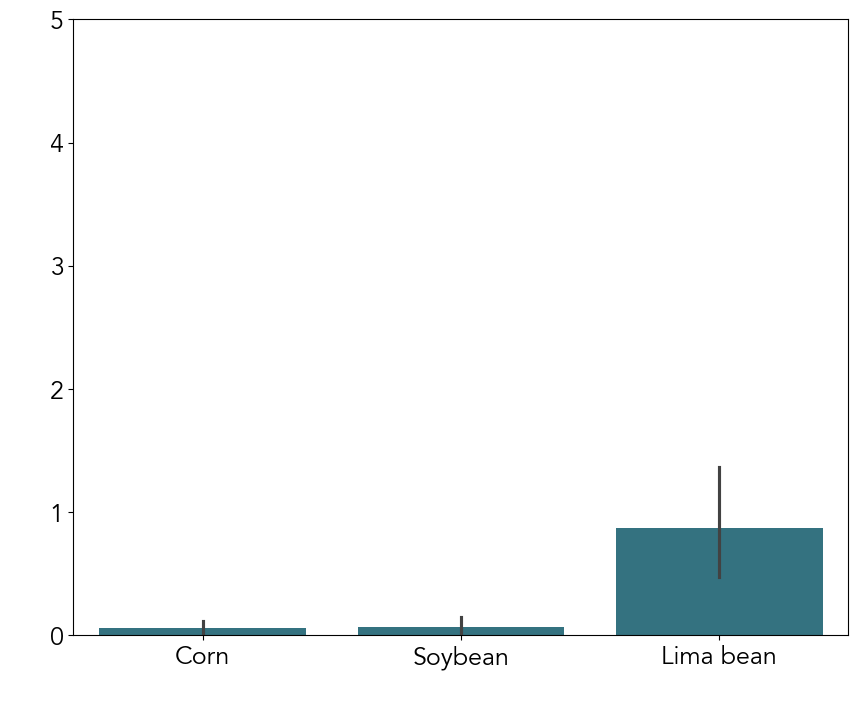

In [232]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(10, 8))

plt.rcParams.update({"font.size": 18})

sns.barplot(
    data=wm,
    x="seed_type",
    y="total_scm",
    color="#287a8c",
    order=["Corn", "Soybean", "Lima bean"],
)

plt.xlabel(" ", labelpad=10)
plt.ylabel(" ", labelpad=10)
plt.ylim(0, 5)
plt.show()


In [233]:
# Mean - SCM per seed.

wm.groupby("seed_type").mean("total_scm")["total_scm"]


seed_type
Corn         0.058824
Lima bean    0.873529
Soybean      0.068627
Name: total_scm, dtype: float64

In [234]:
# SEM - SCM per seed.

wm.groupby("seed_type")["total_scm"].sem()


seed_type
Corn         0.027735
Lima bean    0.230984
Soybean      0.034412
Name: total_scm, dtype: float64

In [235]:
# Kruskal-Wallis test for mean number of SCM per seed.

group1 = wm.loc[wm["seed_type"] == "Corn"]["total_scm"]
group2 = wm.loc[wm["seed_type"] == "Soybean"]["total_scm"]
group3 = wm.loc[wm["seed_type"] == "Lima bean"]["total_scm"]
statistic, p_value = stats.kruskal(group1, group2, group3)
print("Kruskal-Wallis H statistic:", statistic)
print("P-value:", p_value)


Kruskal-Wallis H statistic: 63.85777549840065
P-value: 1.3597536623493051e-14


In [236]:
# Dunn's test for mean number of SCM per seed.

data = [group1, group2, group3]
p_values = sp.posthoc_dunn(data, p_adjust="holm")

print(p_values)


              1             2             3
1  1.000000e+00  8.065956e-01  6.058532e-13
2  8.065956e-01  1.000000e+00  3.001428e-09
3  6.058532e-13  3.001428e-09  1.000000e+00


#### Figure 4B

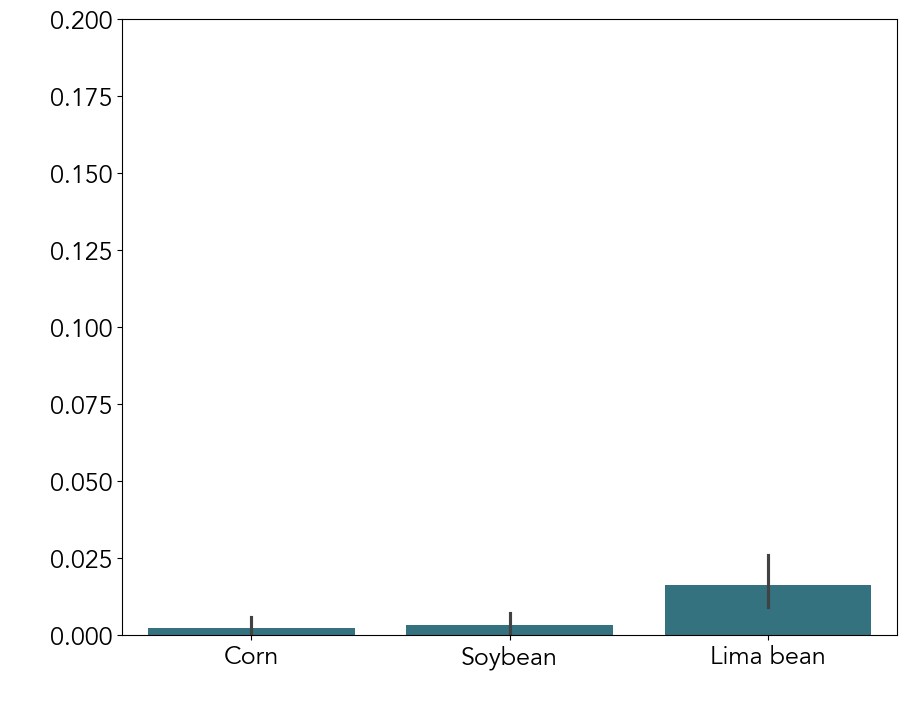

In [237]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(10, 8))

plt.rcParams.update({"font.size": 18})

sns.barplot(
    data=wm.reset_index(),
    x="seed_type",
    y="prop_seeds",
    color="#287a8c",
    order=["Corn", "Soybean", "Lima bean"],
)

plt.xlabel(" ", labelpad=10)
plt.ylabel(" ", labelpad=10)
plt.ylim(0, 0.2)
plt.show()


In [238]:
# Mean - proportion seeds damaged.

wm.groupby("seed_type").mean("prop_seeds")["prop_seeds"]


seed_type
Corn         0.002298
Lima bean    0.016363
Soybean      0.003392
Name: prop_seeds, dtype: float64

In [239]:
# SEM - proportion seeds damaged.

wm.groupby("seed_type")["prop_seeds"].sem()


seed_type
Corn         0.001502
Lima bean    0.004195
Soybean      0.001787
Name: prop_seeds, dtype: float64

In [240]:
# Kruskal-Wallis test for proportion seeds damaged.

group1 = wm.loc[wm["seed_type"] == "Corn"]["prop_seeds"].dropna()
group2 = wm.loc[wm["seed_type"] == "Soybean"]["prop_seeds"].dropna()
group3 = wm.loc[wm["seed_type"] == "Lima bean"]["prop_seeds"].dropna()
statistic, p_value = stats.kruskal(group1, group2, group3)
print("Kruskal-Wallis H statistic:", statistic)
print("P-value:", p_value)


Kruskal-Wallis H statistic: 26.27496269958437
P-value: 1.9699914609002246e-06


In [241]:
# Dunn's test for proportion seeds damaged.

data = [group1, group2, group3]
p_values = sp.posthoc_dunn(data, p_adjust="holm")

print(p_values)


          1         2         3
1  1.000000  0.610519  0.000004
2  0.610519  1.000000  0.000561
3  0.000004  0.000561  1.000000


## Sticky Card Data

In [242]:
# Read and clean 2023 sticky card data.

scm_2023 = pd.read_csv("Data/2023_scm_counts.csv")
scm_2023 = clean_columns(scm_2023)
scm_2023["date_collected"] = pd.to_datetime(
    scm_2023["date_collected"], format="%m/%d/%y"
)

scm_2023[
    [
        "n_scm_i_m",
        "n_scm_o_m",
        "n_scm_i_f",
        "n_scm_o_f",
        "n_d_florilega_i",
        "n_d_florilega_o",
    ]
] = scm_2023[
    [
        "n_scm_i_m",
        "n_scm_o_m",
        "n_scm_i_f",
        "n_scm_o_f",
        "n_d_florilega_i",
        "n_d_florilega_o",
    ]
].apply(
    pd.to_numeric, errors="coerce"
)
scm_2023["scm_male"] = scm_2023["n_scm_i_m"] + scm_2023["n_scm_o_m"]
scm_2023["scm_female"] = scm_2023["n_scm_i_f"] + scm_2023["n_scm_o_f"]
scm_2023["total_scm"] = (
    scm_2023["n_scm_i_m"]
    + scm_2023["n_scm_o_m"]
    + scm_2023["n_scm_i_f"]
    + scm_2023["n_scm_o_f"]
)
scm_2023 = scm_2023.dropna(subset=["total_scm"])
scm_2023["florilega"] = scm_2023["n_d_florilega_i"] + scm_2023["n_d_florilega_o"]
scm_2023["total_flies"] = scm_2023["total_scm"] + scm_2023["florilega"]

scm_2023["week"] = scm_2023["date_collected"].dt.isocalendar().week.astype(int)
scm_2023["year"] = scm_2023["date_collected"].dt.isocalendar().year

scm_2023.head()


/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/3782844111.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2023["florilega"] = scm_2023["n_d_florilega_i"] + scm_2023["n_d_florilega_o"]
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/3782844111.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2023["total_flies"] = scm_2023["total_scm"] + scm_2023["florilega"]
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/3782844111.py:42: SettingWithCopyWa

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,total_scm,florilega,total_flies,week,year
1,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,304.0,24.0,328.0,25,2023
2,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,81.0,1.0,82.0,24,2023
4,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,18.0,0.0,18.0,22,2023
7,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,100.0,0.0,100.0,21,2023
9,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,28.0,0.0,28.0,20,2023


In [243]:
scm_2024 = pd.read_csv("Data/2024_scm_counts.csv")
scm_2024 = clean_columns(scm_2024)
scm_2024["date_collected"] = pd.to_datetime(scm_2024["date_collected"], format="mixed")

scm_2024["scm_male"] = scm_2024["n_scm_m_1"] + scm_2024["n_scm_m_2"]
scm_2024["scm_female"] = scm_2024["n_scm_f_1"] + scm_2024["n_scm_f_2"]
scm_2024["total_scm"] = (
    scm_2024["n_scm_m_1"]
    + scm_2024["n_scm_m_2"]
    + scm_2024["n_scm_f_1"]
    + scm_2024["n_scm_f_2"]
)
scm_2024["florilega"] = scm_2024["n_d_florilega_1"] + scm_2024["n_d_florilega_2"]
scm_2024["total_flies"] = scm_2024["florilega"] + scm_2024["total_scm"]
scm_2024 = scm_2024.dropna(subset=["total_scm"])

scm_2024["week"] = scm_2024["date_collected"].dt.isocalendar().week.astype(int)
scm_2024["year"] = scm_2024["date_collected"].dt.isocalendar().year

scm_2024.head()


/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/3931764245.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2024["week"] = scm_2024["date_collected"].dt.isocalendar().week.astype(int)
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/3931764245.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2024["year"] = scm_2024["date_collected"].dt.isocalendar().year


,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,total_scm,florilega,total_flies,week,year
0,DEG_DIE_2,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,195.0,4.0,199.0,20,2024
5,DEG_DIE_2,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,15.0,0.0,15.0,22,2024
6,DEG_DIE_2,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,163.0,55.0,218.0,23,2024
8,DEG_DIE_2,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,205.0,23.0,228.0,24,2024
11,DEG_DIE_2,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,86.0,31.0,117.0,25,2024


In [244]:
sticky_cards_merged = pd.concat([scm_2023, scm_2024])
sticky_cards_merged.head()


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,florilega,total_flies,week,year,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
1,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,24.0,328.0,25,2023,NaN,NaN,NaN,NaN,NaN,NaN
2,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,1.0,82.0,24,2023,NaN,NaN,NaN,NaN,NaN,NaN
4,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.0,18.0,22,2023,NaN,NaN,NaN,NaN,NaN,NaN
7,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.0,100.0,21,2023,NaN,NaN,NaN,NaN,NaN,NaN
9,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.0,28.0,20,2023,NaN,NaN,NaN,NaN,NaN,NaN


#### Fig. 5A

(9.0, 52.0)

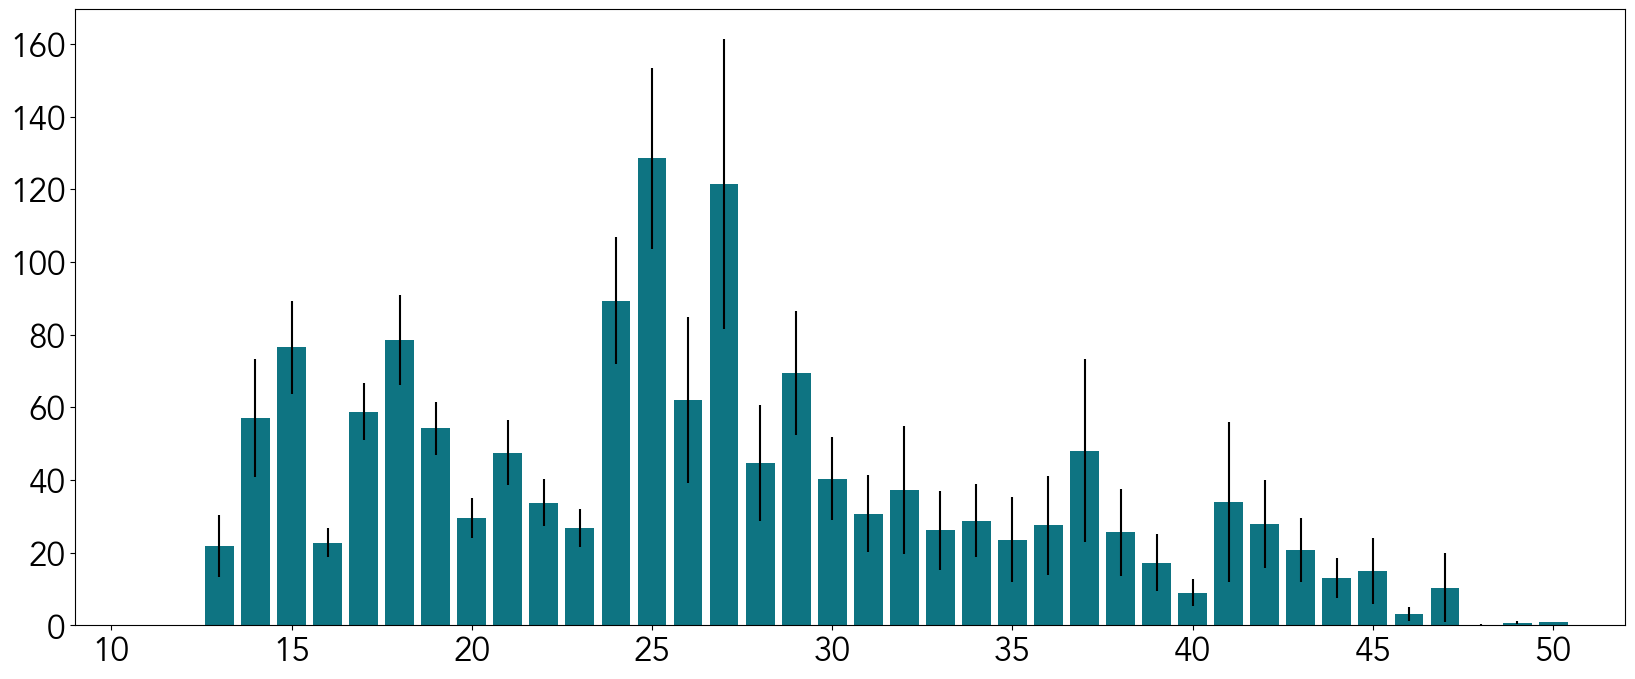

In [245]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(20, 8))
plt.rcParams.update({"font.size": 24})

grouped_2023 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2023]
    .groupby("week")["total_flies"]
    .mean()
    .reset_index()
)
se_2023 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2023]
    .groupby("week")["total_flies"]
    .sem()
    .reset_index()
)

plt.bar(grouped_2023["week"], grouped_2023["total_flies"], color="#0e7482")
plt.errorbar(
    x=grouped_2023["week"],
    y=grouped_2023["total_flies"],
    yerr=se_2023["total_flies"],
    ecolor="black",
    fmt="None",
)
plt.xlim(9, 52)


#### Fig. 5B

(9.0, 52.0)

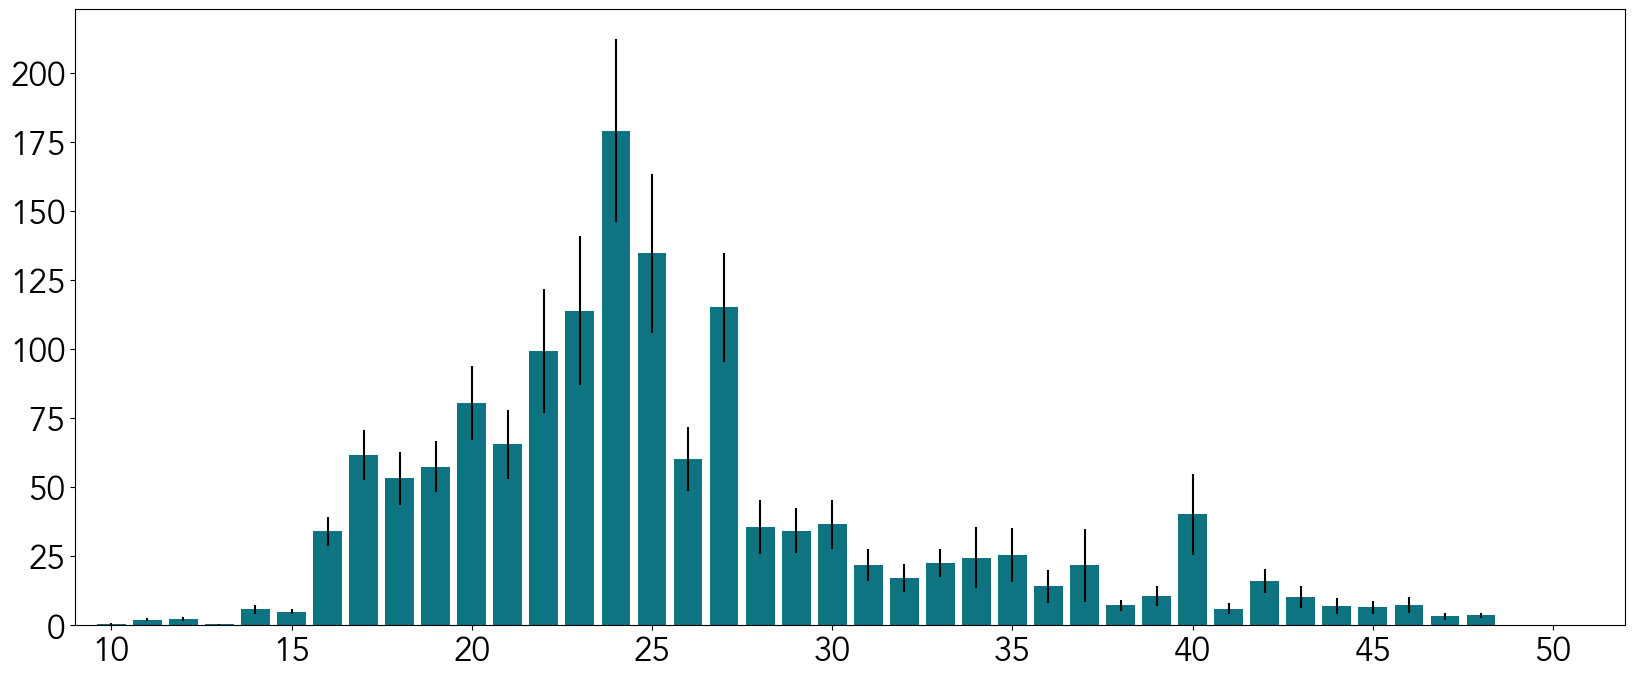

In [246]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(20, 8))
plt.rcParams.update({"font.size": 24})


grouped_2024 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2024]
    .groupby("week")["total_flies"]
    .mean()
    .reset_index()
)
se_2024 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2024]
    .groupby("week")["total_flies"]
    .sem()
    .reset_index()
)

plt.bar(grouped_2024["week"], grouped_2024["total_flies"], color="#0e7482")
plt.errorbar(
    x=grouped_2024["week"],
    y=grouped_2024["total_flies"],
    yerr=se_2024["total_flies"],
    ecolor="black",
    fmt="None",
)
plt.xlim(9, 52)


## Climate

In [247]:
climate_2023 = pd.read_csv("Data/2023_climate.csv")
climate_2023["date"] = pd.to_datetime(climate_2023["date"], format="%m/%d/%y")
climate_2023["week"] = climate_2023["date"].dt.isocalendar().week
climate_2023 = (
    climate_2023[
        [
            "field_id",
            "week",
            "ppt_in",
            "tmin_f",
            "tmean_f",
            "tmax_f",
            "tdmean_f",
            "vpdmin_hPa",
            "vpdmax_hPa",
        ]
    ]
    .groupby(["field_id", "week"])
    .mean()
)
climate_2023["year"] = 2023
climate_2023 = climate_2023.reset_index()
climate_2023.head()


,field_id,week,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa,year
0,DEG_DIE_HILL,1,0.144286,33.014286,39.142857,45.214286,35.685714,0.241429,2.728571,2023
1,DEG_DIE_HILL,2,0.114286,22.571429,27.885714,33.185714,24.714286,0.288571,1.651429,2023
2,DEG_DIE_HILL,3,0.168571,24.700000,29.342857,33.971429,27.071429,0.171429,1.292857,2023
3,DEG_DIE_HILL,4,0.111429,24.385714,29.571429,34.742857,24.800000,0.218571,2.294286,2023
4,DEG_DIE_HILL,5,0.018571,5.085714,15.485714,25.900000,10.642857,0.175714,2.072857,2023


In [248]:
climate_2024 = pd.read_csv("Data/2024_climate.csv")
climate_2024["date"] = pd.to_datetime(climate_2024["date"], format="%m/%d/%y")
climate_2024["week"] = climate_2024["date"].dt.isocalendar().week
climate_2024 = (
    climate_2024[
        [
            "field_id",
            "week",
            "ppt_in",
            "tmin_f",
            "tmean_f",
            "tmax_f",
            "tdmean_f",
            "vpdmin_hPa",
            "vpdmax_hPa",
        ]
    ]
    .groupby(["field_id", "week"])
    .mean()
)
climate_2024["year"] = 2024
climate_2024 = climate_2024.reset_index()

dict = {
    "DEG_DIE_HILL": "DEG_DIE_2",
    "DEG_FOU_WOOD": "DEG_FOU_2",
    "DEG_PER_STRI": "DEG_PER_2",
    "DEG_VIL": "DEG_VIL_2",
}
climate_2024 = climate_2024.replace({"field_id": dict})
climate_2024.head()


,field_id,week,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa,year
0,DEG_DIE_2,1,0.100000,25.822222,30.622222,35.455556,26.866667,0.253333,1.995556,2024
1,DEG_DIE_2,2,0.215714,28.842857,33.657143,38.471429,28.828571,0.174286,2.194286,2024
2,DEG_DIE_2,3,0.045714,8.271429,14.371429,20.471429,7.671429,0.300000,1.532857,2024
3,DEG_DIE_2,4,0.332857,25.000000,31.500000,37.971429,29.028571,0.091429,1.611429,2024
4,DEG_DIE_2,5,0.118571,27.171429,30.285714,33.414286,27.642857,0.270000,1.182857,2024


In [249]:
# Data cleaning for consistent site naming.

scm_2023 = scm_2023.replace({"SMI_JOH ": "SMI_JOH"})
scm_2023 = scm_2023[scm_2023.field_id != "ZUE_FLE"]

scm_2024 = scm_2024.replace({"SMI_JOH ": "SMI_JOH"})
scm_2024 = scm_2024[scm_2024.field_id != "ZUE_FLE"]

dict = {
    "DEG_PER_STRI": "DEG_PER_STRIP",
    "DEG_YOU_BOCE": "DEG_YOU_BOCES",
    "DEG_YOU_JONE": "DEG_YOU_JONES",
    "DEG_YOU_OSHE": "DEG_YOU_OSHEA",
}
climate_2023 = climate_2023.replace({"field_id": dict})
climate_2024 = climate_2024.replace({"field_id": dict})

dict = {
    "DEG_DIE_HILL": "DEG_DIE_2",
    "DEG_FOU_WOOD": "DEG_FOU_2",
    "DEG_PER_STRIP": "DEG_PER_2",
    "DEG_VIL": "DEG_VIL_2",
    "KAT_TEE_2": "KAT_TEE_3",
    "SMI_COB": "SMI_COB_3",
}
scm_2024 = scm_2024.replace({"field_id": dict})


In [250]:
# Merge sticky card data and climate data 2023.

scm_2023 = scm_2023.merge(climate_2023, on=["field_id", "week", "year"])
scm_2023.head()


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,total_flies,week,year,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,328.0,25,2023,0.171429,56.971429,66.414286,75.857143,57.942857,0.822857,13.818571
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,82.0,24,2023,0.340000,54.128571,61.800000,69.514286,52.514286,1.064286,12.205714
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,18.0,22,2023,0.000000,49.985714,66.228571,82.428571,47.800000,1.715714,27.422857
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,100.0,21,2023,0.002857,40.285714,54.400000,68.485714,41.442857,0.651429,15.135714
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,28.0,20,2023,0.018571,37.685714,50.642857,63.628571,35.571429,1.245714,13.838571


In [251]:
# Merge sticky card data and climate data 2024.

scm_2024 = scm_2024.merge(climate_2024, on=["field_id", "week", "year"])
scm_2024.head()


,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,total_flies,week,year,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa
0,DEG_DIE_2,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,199.0,20,2024,0.070000,51.385714,58.714286,66.071429,52.728571,0.244286,8.314286
1,DEG_DIE_2,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,15.0,22,2024,0.061429,48.214286,58.757143,69.271429,48.071429,0.731429,13.367143
2,DEG_DIE_2,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,218.0,23,2024,0.378571,55.442857,65.000000,74.571429,56.842857,0.458571,13.478571
3,DEG_DIE_2,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,228.0,24,2024,0.061429,50.371429,59.671429,68.942857,51.100000,0.625714,12.370000
4,DEG_DIE_2,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,117.0,25,2024,0.062857,64.928571,75.285714,85.628571,65.585714,1.124286,19.827143


## Landscape

In [252]:
# Read all landscape data for 2023 and 2024, at both 500m and 1000m radii.

sites_2023_cdl_2022_500m = pd.read_csv(
    "Landscape/Cleaned Landscape/2023_sites_2022_cdl_500m.csv"
)
sites_2023_cdl_2022_1000m = pd.read_csv(
    "Landscape/Cleaned Landscape/2023_sites_2022_cdl_1000m.csv"
)

sites_2023_cdl_2023_500m = pd.read_csv(
    "Landscape/Cleaned Landscape/2023_sites_2023_cdl_500m.csv"
)
sites_2023_cdl_2023_1000m = pd.read_csv(
    "Landscape/Cleaned Landscape/2023_sites_2023_cdl_1000m.csv"
)

sites_2024_cdl_2023_500m = pd.read_csv(
    "Landscape/Cleaned Landscape/2024_sites_2023_cdl_500m.csv"
)
sites_2024_cdl_2023_1000m = pd.read_csv(
    "Landscape/Cleaned Landscape/2024_sites_2023_cdl_1000m.csv"
)

sites_2024_cdl_2024_500m = pd.read_csv(
    "Landscape/Cleaned Landscape/2024_sites_2024_cdl_500m.csv"
)
sites_2024_cdl_2024_1000m = pd.read_csv(
    "Landscape/Cleaned Landscape/2024_sites_2024_cdl_1000m.csv"
)


In [253]:
# Calculate proportion of landscape types - 2023 sticky card data, 2022 CDL, 500m radius.

sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m[
    [
        "Name",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2023_cdl_2022_500m["Prop Corn"] = (
    sites_2023_cdl_2022_500m["Corn"] + sites_2023_cdl_2022_500m["Sweet Corn"]
) / sites_2023_cdl_2022_500m["Total"]
sites_2023_cdl_2022_500m["Prop Soy"] = (
    sites_2023_cdl_2022_500m["Soybeans"] / sites_2023_cdl_2022_500m["Total"]
)
sites_2023_cdl_2022_500m["Prop Ag"] = (
    sites_2023_cdl_2022_500m["Ag"] / sites_2023_cdl_2022_500m["Total"]
)
sites_2023_cdl_2022_500m["Prop Nat"] = (
    sites_2023_cdl_2022_500m["Nat"] / sites_2023_cdl_2022_500m["Total"]
)
sites_2023_cdl_2022_500m["Prop Semi Nat"] = (
    sites_2023_cdl_2022_500m["Grassland/Pasture"] / sites_2023_cdl_2022_500m["Total"]
)
sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m.add_suffix("_PreviousYear_500m")
sites_2023_cdl_2022_500m = clean_columns(sites_2023_cdl_2022_500m)
sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m.rename(
    columns={"name_previous_year_500m": "field_id"}
)
sites_2023_cdl_2022_500m.head()


,field_id,corn_previous_year_500m,sweet_corn_previous_year_500m,soybeans_previous_year_500m,ag_previous_year_500m,nat_previous_year_500m,total_previous_year_500m,grassland_pasture_previous_year_500m,prop_corn_previous_year_500m,prop_soy_previous_year_500m,prop_ag_previous_year_500m,prop_nat_previous_year_500m,prop_semi_nat_previous_year_500m
0,POV_DUN,11,0,3,171,753,1588,526,0.006927,0.001889,0.107683,0.474181,0.331234
1,DIP_FLE,706,0,11,931,305,1603,278,0.440424,0.006862,0.580786,0.190268,0.173425
2,DIP_CUR,540,0,50,978,212,1593,255,0.338983,0.031387,0.613936,0.133082,0.160075
3,GAB_STE,252,0,0,408,914,1627,211,0.154886,0.000000,0.250768,0.561770,0.129687
4,SMI_CRO,712,0,344,1347,29,1611,168,0.441962,0.213532,0.836127,0.018001,0.104283


In [254]:
# Calculate proportion of landscape types - 2023 sticky card data, 2022 CDL, 1000m radius.

sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m[
    [
        "Name",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2023_cdl_2022_1000m["Prop Corn"] = (
    sites_2023_cdl_2022_1000m["Corn"] + sites_2023_cdl_2022_1000m["Sweet Corn"]
) / sites_2023_cdl_2022_1000m["Total"]
sites_2023_cdl_2022_1000m["Prop Soy"] = (
    sites_2023_cdl_2022_1000m["Soybeans"] / sites_2023_cdl_2022_1000m["Total"]
)
sites_2023_cdl_2022_1000m["Prop Ag"] = (
    sites_2023_cdl_2022_1000m["Ag"] / sites_2023_cdl_2022_1000m["Total"]
)
sites_2023_cdl_2022_1000m["Prop Nat"] = (
    sites_2023_cdl_2022_1000m["Nat"] / sites_2023_cdl_2022_1000m["Total"]
)
sites_2023_cdl_2022_1000m["Prop Semi Nat"] = (
    sites_2023_cdl_2022_1000m["Grassland/Pasture"] / sites_2023_cdl_2022_1000m["Total"]
)
sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m.add_suffix("_PreviousYear_1000m")
sites_2023_cdl_2022_1000m = clean_columns(sites_2023_cdl_2022_1000m)
sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m.rename(
    columns={"name_previous_year_1000m": "field_id"}
)
sites_2023_cdl_2022_1000m.head()


,field_id,corn_previous_year_1000m,sweet_corn_previous_year_1000m,soybeans_previous_year_1000m,ag_previous_year_1000m,nat_previous_year_1000m,total_previous_year_1000m,grassland_pasture_previous_year_1000m,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m
0,POV_DUN,17,0,3,744,3104,6362,1666,0.002672,0.000472,0.116944,0.487897,0.261867
1,DIP_FLE,1985,30,34,4466,921,6399,746,0.314893,0.005313,0.697922,0.143929,0.116581
2,DIP_CUR,2231,0,402,3908,1079,6369,881,0.350290,0.063118,0.613597,0.169414,0.138326
3,GAB_STE,665,0,1,1429,4110,6499,763,0.102323,0.000154,0.219880,0.632405,0.117403
4,SMI_CRO,1395,0,948,4520,651,6454,987,0.216145,0.146886,0.700341,0.100868,0.152928


In [255]:
# Calculate proportion of landscape types - 2023 sticky card data, 2023 CDL, 500m radius.

sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m[
    [
        "Name",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2023_cdl_2023_500m["Prop Corn"] = (
    sites_2023_cdl_2023_500m["Corn"] + sites_2023_cdl_2023_500m["Sweet Corn"]
) / sites_2023_cdl_2023_500m["Total"]
sites_2023_cdl_2023_500m["Prop Soy"] = (
    sites_2023_cdl_2023_500m["Soybeans"] / sites_2023_cdl_2023_500m["Total"]
)
sites_2023_cdl_2023_500m["Prop Ag"] = (
    sites_2023_cdl_2023_500m["Ag"] / sites_2023_cdl_2023_500m["Total"]
)
sites_2023_cdl_2023_500m["Prop Nat"] = (
    sites_2023_cdl_2023_500m["Nat"] / sites_2023_cdl_2023_500m["Total"]
)
sites_2023_cdl_2023_500m["Prop Semi Nat"] = (
    sites_2023_cdl_2023_500m["Grassland/Pasture"] / sites_2023_cdl_2023_500m["Total"]
)
sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m.add_suffix("_CurrentYear_500m")
sites_2023_cdl_2023_500m = clean_columns(sites_2023_cdl_2023_500m)
sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m.rename(
    columns={"name_current_year_500m": "field_id"}
)
sites_2023_cdl_2023_500m.head()


,field_id,corn_current_year_500m,sweet_corn_current_year_500m,soybeans_current_year_500m,ag_current_year_500m,nat_current_year_500m,total_current_year_500m,grassland_pasture_current_year_500m,prop_corn_current_year_500m,prop_soy_current_year_500m,prop_ag_current_year_500m,prop_nat_current_year_500m,prop_semi_nat_current_year_500m
0,POV_DUN,9,0,4,102,1539,3209,876,0.002805,0.001246,0.031786,0.479589,0.272982
1,DIP_FLE,969,5,18,1947,469,3220,392,0.302484,0.005590,0.604658,0.145652,0.121739
2,DIP_CUR,991,0,223,1764,527,3211,462,0.308627,0.069449,0.549362,0.164123,0.143880
3,GAB_STE,289,1,0,607,2063,3243,393,0.089423,0.000000,0.187172,0.636139,0.121184
4,SMI_CRO,577,0,560,1458,327,3232,554,0.178527,0.173267,0.451114,0.101176,0.171411


In [256]:
# Calculate proportion of landscape types - 2023 sticky card data, 2023 CDL, 1000m radius.

sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m[
    [
        "Name",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2023_cdl_2023_1000m["Prop Corn"] = (
    sites_2023_cdl_2023_1000m["Corn"] + sites_2023_cdl_2023_1000m["Sweet Corn"]
) / sites_2023_cdl_2023_1000m["Total"]
sites_2023_cdl_2023_1000m["Prop Soy"] = (
    sites_2023_cdl_2023_1000m["Soybeans"] / sites_2023_cdl_2023_1000m["Total"]
)
sites_2023_cdl_2023_1000m["Prop Ag"] = (
    sites_2023_cdl_2023_1000m["Ag"] / sites_2023_cdl_2023_1000m["Total"]
)
sites_2023_cdl_2023_1000m["Prop Nat"] = (
    sites_2023_cdl_2023_1000m["Nat"] / sites_2023_cdl_2023_1000m["Total"]
)
sites_2023_cdl_2023_1000m["Prop Semi Nat"] = (
    sites_2023_cdl_2023_1000m["Grassland/Pasture"] / sites_2023_cdl_2023_1000m["Total"]
)
sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m.add_suffix("_CurrentYear_1000m")
sites_2023_cdl_2023_1000m = clean_columns(sites_2023_cdl_2023_1000m)
sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m.rename(
    columns={"name_current_year_1000m": "field_id"}
)
sites_2023_cdl_2023_1000m.head()


,field_id,corn_current_year_1000m,sweet_corn_current_year_1000m,soybeans_current_year_1000m,ag_current_year_1000m,nat_current_year_1000m,total_current_year_1000m,grassland_pasture_current_year_1000m,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m
0,POV_DUN,9,0,4,102,1539,3209,876,0.002805,0.001246,0.031786,0.479589,0.272982
1,DIP_FLE,969,5,18,1947,469,3220,392,0.302484,0.005590,0.604658,0.145652,0.121739
2,DIP_CUR,991,0,223,1764,527,3211,462,0.308627,0.069449,0.549362,0.164123,0.143880
3,GAB_STE,289,1,0,607,2063,3243,393,0.089423,0.000000,0.187172,0.636139,0.121184
4,SMI_CRO,577,0,560,1458,327,3232,554,0.178527,0.173267,0.451114,0.101176,0.171411


In [257]:
# Calculate proportion of landscape types - 2024 sticky card data, 2023 CDL, 500m radius.

sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m[
    [
        "Field ID",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2024_cdl_2023_500m["Prop Corn"] = (
    sites_2024_cdl_2023_500m["Corn"] + sites_2024_cdl_2023_500m["Sweet Corn"]
) / sites_2024_cdl_2023_500m["Total"]
sites_2024_cdl_2023_500m["Prop Soy"] = (
    sites_2024_cdl_2023_500m["Soybeans"] / sites_2024_cdl_2023_500m["Total"]
)
sites_2024_cdl_2023_500m["Prop Ag"] = (
    sites_2024_cdl_2023_500m["Ag"] / sites_2024_cdl_2023_500m["Total"]
)
sites_2024_cdl_2023_500m["Prop Nat"] = (
    sites_2024_cdl_2023_500m["Nat"] / sites_2024_cdl_2023_500m["Total"]
)
sites_2024_cdl_2023_500m["Prop Semi Nat"] = (
    sites_2024_cdl_2023_500m["Grassland/Pasture"] / sites_2024_cdl_2023_500m["Total"]
)
sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m.add_suffix("_PreviousYear_500m")
sites_2024_cdl_2023_500m = clean_columns(sites_2024_cdl_2023_500m)
sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m.rename(
    columns={"field_id_previous_year_500m": "field_id"}
)
sites_2024_cdl_2023_500m.head()


,field_id,corn_previous_year_500m,sweet_corn_previous_year_500m,soybeans_previous_year_500m,ag_previous_year_500m,nat_previous_year_500m,total_previous_year_500m,grassland_pasture_previous_year_500m,prop_corn_previous_year_500m,prop_soy_previous_year_500m,prop_ag_previous_year_500m,prop_nat_previous_year_500m,prop_semi_nat_previous_year_500m
0,DEG_DIE_HILL,297,0,6,483,36,809,139,0.367120,0.007417,0.597033,0.044499,0.171817
1,DEG_FOU_WOOD,338,0,2,409,25,804,155,0.420398,0.002488,0.508706,0.031095,0.192786
2,DEG_PER_STRIP,192,0,57,463,92,805,147,0.238509,0.070807,0.575155,0.114286,0.182609
3,DEG_VIL,446,4,19,485,78,806,104,0.558313,0.023573,0.601737,0.096774,0.129032
4,DIP_CUR,311,0,6,444,111,800,124,0.388750,0.007500,0.555000,0.138750,0.155000


In [258]:
# Calculate proportion of landscape types - 2024 sticky card data, 2023 CDL, 1000m radius.

sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m[
    [
        "Field ID",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2024_cdl_2023_1000m["Prop Corn"] = (
    sites_2024_cdl_2023_1000m["Corn"] + sites_2024_cdl_2023_1000m["Sweet Corn"]
) / sites_2024_cdl_2023_1000m["Total"]
sites_2024_cdl_2023_1000m["Prop Soy"] = (
    sites_2024_cdl_2023_1000m["Soybeans"] / sites_2024_cdl_2023_1000m["Total"]
)
sites_2024_cdl_2023_1000m["Prop Ag"] = (
    sites_2024_cdl_2023_1000m["Ag"] / sites_2024_cdl_2023_1000m["Total"]
)
sites_2024_cdl_2023_1000m["Prop Nat"] = (
    sites_2024_cdl_2023_1000m["Nat"] / sites_2024_cdl_2023_1000m["Total"]
)
sites_2024_cdl_2023_1000m["Prop Semi Nat"] = (
    sites_2024_cdl_2023_1000m["Grassland/Pasture"] / sites_2024_cdl_2023_1000m["Total"]
)
sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m.add_suffix("_PreviousYear_1000m")
sites_2024_cdl_2023_1000m = clean_columns(sites_2024_cdl_2023_1000m)
sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m.rename(
    columns={"field_id_previous_year_1000m": "field_id"}
)
sites_2024_cdl_2023_1000m.head()


,field_id,corn_previous_year_1000m,sweet_corn_previous_year_1000m,soybeans_previous_year_1000m,ag_previous_year_1000m,nat_previous_year_1000m,total_previous_year_1000m,grassland_pasture_previous_year_1000m,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m
0,DEG_DIE_HILL,481,1,11,1003,633,3220,599,0.149689,0.003416,0.311491,0.196584,0.186025
1,DEG_FOU_WOOD,991,0,7,1335,615,3228,560,0.307001,0.002169,0.413569,0.190520,0.173482
2,DEG_PER_STRIP,708,0,125,1319,1033,3227,447,0.219399,0.038736,0.408739,0.320112,0.138519
3,DEG_VIL,994,4,45,1394,679,3226,452,0.309361,0.013949,0.432114,0.210477,0.140112
4,DIP_CUR,991,0,223,1764,527,3211,462,0.308627,0.069449,0.549362,0.164123,0.143880


In [259]:
# Calculate proportion of landscape types - 2024 sticky card data, 2024 CDL, 500m radius.

sites_2024_cdl_2024_500m = sites_2024_cdl_2024_500m[
    [
        "Field ID",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2024_cdl_2024_500m["Prop Corn"] = (
    sites_2024_cdl_2024_500m["Corn"] + sites_2024_cdl_2024_500m["Sweet Corn"]
) / sites_2024_cdl_2024_500m["Total"]
sites_2024_cdl_2024_500m["Prop Soy"] = (
    sites_2024_cdl_2024_500m["Soybeans"] / sites_2024_cdl_2024_500m["Total"]
)
sites_2024_cdl_2024_500m["Prop Ag"] = (
    sites_2024_cdl_2024_500m["Ag"] / sites_2024_cdl_2024_500m["Total"]
)
sites_2024_cdl_2024_500m["Prop Nat"] = (
    sites_2024_cdl_2024_500m["Nat"] / sites_2024_cdl_2024_500m["Total"]
)
sites_2024_cdl_2024_500m["Prop Semi Nat"] = (
    sites_2024_cdl_2024_500m["Grassland/Pasture"] / sites_2024_cdl_2024_500m["Total"]
)
sites_2024_cdl_2024_500m = sites_2024_cdl_2024_500m.add_suffix("_CurrentYear_500m")
sites_2024_cdl_2024_500m = clean_columns(sites_2024_cdl_2024_500m)
sites_2024_cdl_2024_500m = sites_2024_cdl_2024_500m.rename(
    columns={"field_id_current_year_500m": "field_id"}
)
sites_2024_cdl_2024_500m.head()


,field_id,corn_current_year_500m,sweet_corn_current_year_500m,soybeans_current_year_500m,ag_current_year_500m,nat_current_year_500m,total_current_year_500m,grassland_pasture_current_year_500m,prop_corn_current_year_500m,prop_soy_current_year_500m,prop_ag_current_year_500m,prop_nat_current_year_500m,prop_semi_nat_current_year_500m
0,DEG_DIE_HILL,163,0,261,499,44,865,265,0.188439,0.301734,0.576879,0.050867,0.306358
1,DEG_FOU_WOOD,294,0,0,391,53,866,336,0.339492,0.000000,0.451501,0.061201,0.387991
2,DEG_PER_STRIP,148,0,168,391,110,869,324,0.170311,0.193326,0.449942,0.126582,0.372842
3,DEG_VIL,471,4,23,516,141,866,103,0.548499,0.026559,0.595843,0.162818,0.118938
4,DIP_CUR,95,1,33,279,151,865,363,0.110983,0.038150,0.322543,0.174566,0.419653


In [260]:
# Calculate proportion of landscape types - 2024 sticky card data, 2024 CDL, 1000m radius.

sites_2024_cdl_2024_1000m = sites_2024_cdl_2024_1000m[
    [
        "Field ID",
        "Corn",
        "Sweet Corn",
        "Soybeans",
        "Ag",
        "Nat",
        "Total",
        "Grassland/Pasture",
    ]
]
sites_2024_cdl_2024_1000m["Prop Corn"] = (
    sites_2024_cdl_2024_1000m["Corn"] + sites_2024_cdl_2024_1000m["Sweet Corn"]
) / sites_2024_cdl_2024_1000m["Total"]
sites_2024_cdl_2024_1000m["Prop Soy"] = (
    sites_2024_cdl_2024_1000m["Soybeans"] / sites_2024_cdl_2024_1000m["Total"]
)
sites_2024_cdl_2024_1000m["Prop Ag"] = (
    sites_2024_cdl_2024_1000m["Ag"] / sites_2024_cdl_2024_1000m["Total"]
)
sites_2024_cdl_2024_1000m["Prop Nat"] = (
    sites_2024_cdl_2024_1000m["Nat"] / sites_2024_cdl_2024_1000m["Total"]
)
sites_2024_cdl_2024_1000m["Prop Semi Nat"] = (
    sites_2024_cdl_2024_1000m["Grassland/Pasture"] / sites_2024_cdl_2024_1000m["Total"]
)
sites_2024_cdl_2024_1000m = sites_2024_cdl_2024_1000m.add_suffix("_CurrentYear_1000m")
sites_2024_cdl_2024_1000m = clean_columns(sites_2024_cdl_2024_1000m)
sites_2024_cdl_2024_1000m = sites_2024_cdl_2024_1000m.rename(
    columns={"field_id_current_year_1000m": "field_id"}
)
sites_2024_cdl_2024_1000m.head()


,field_id,corn_current_year_1000m,sweet_corn_current_year_1000m,soybeans_current_year_1000m,ag_current_year_1000m,nat_current_year_1000m,total_current_year_1000m,grassland_pasture_current_year_1000m,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m
0,DEG_DIE_HILL,574,2,276,990,719,3465,926,0.166234,0.079654,0.285714,0.207504,0.267244
1,DEG_FOU_WOOD,848,0,49,1177,727,3460,1308,0.245087,0.014162,0.340173,0.210116,0.378035
2,DEG_PER_STRIP,811,0,254,1270,1193,3467,818,0.233920,0.073262,0.366311,0.344102,0.235939
3,DEG_VIL,952,4,140,1319,899,3464,739,0.275982,0.040416,0.380774,0.259527,0.213337
4,DIP_CUR,833,1,398,1678,707,3464,856,0.240762,0.114896,0.484411,0.204099,0.247113


In [261]:
# Merge 2023 sticky card data with corresponding landscape data.

scm_2023 = scm_2023.merge(sites_2023_cdl_2023_500m, on="field_id")
scm_2023 = scm_2023.merge(sites_2023_cdl_2023_1000m, on="field_id")
scm_2023 = scm_2023.merge(sites_2023_cdl_2022_500m, on="field_id")
scm_2023 = scm_2023.merge(sites_2023_cdl_2022_1000m, on="field_id")
scm_2023 = scm_2023.drop(
    [
        "corn_previous_year_500m",
        "sweet_corn_previous_year_500m",
        "ag_previous_year_500m",
        "nat_previous_year_500m",
        "total_previous_year_500m",
        "corn_previous_year_1000m",
        "sweet_corn_previous_year_1000m",
        "ag_previous_year_1000m",
        "nat_previous_year_1000m",
        "total_previous_year_1000m",
        "corn_current_year_500m",
        "sweet_corn_current_year_500m",
        "ag_current_year_500m",
        "nat_current_year_500m",
        "total_current_year_500m",
        "corn_current_year_1000m",
        "sweet_corn_current_year_1000m",
        "ag_current_year_1000m",
        "nat_current_year_1000m",
        "total_current_year_1000m",
        "grassland_pasture_current_year_500m",
        "grassland_pasture_current_year_1000m",
        "grassland_pasture_previous_year_500m",
        "grassland_pasture_previous_year_1000m",
    ],
    axis=1,
)
scm_2023.head()


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,prop_soy_previous_year_500m,prop_ag_previous_year_500m,prop_nat_previous_year_500m,prop_semi_nat_previous_year_500m,soybeans_previous_year_1000m,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,0.236181,0.600503,0.123116,0.21294,441,0.124902,0.068852,0.354723,0.177674,0.209524
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,0.236181,0.600503,0.123116,0.21294,441,0.124902,0.068852,0.354723,0.177674,0.209524
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.236181,0.600503,0.123116,0.21294,441,0.124902,0.068852,0.354723,0.177674,0.209524
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.236181,0.600503,0.123116,0.21294,441,0.124902,0.068852,0.354723,0.177674,0.209524
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.236181,0.600503,0.123116,0.21294,441,0.124902,0.068852,0.354723,0.177674,0.209524


In [262]:
# Clean site names in landscape data for consistency .

dict = {
    "DEG_DIE_2": "DEG_DIE_HILL",
    "DEG_FOU_2": "DEG_FOU_WOOD",
    "DEG_PER_2": "DEG_PER_STRIP",
    "DEG_VIL_2": "DEG_VIL",
    "KAT_TEE_2": "KAT_TEE_3",
    "SMI_COB": "SMI_COB_3",
}
scm_2024 = scm_2024.replace({"field_id": dict})


In [263]:
# Merge 2024 sticky card data with corresponding landscape data.

scm_2024 = scm_2024.merge(sites_2024_cdl_2023_500m, on="field_id")
scm_2024 = scm_2024.merge(sites_2024_cdl_2023_1000m, on="field_id")
scm_2024 = scm_2024.merge(sites_2024_cdl_2024_500m, on="field_id")
scm_2024 = scm_2024.merge(sites_2024_cdl_2024_1000m, on="field_id")
scm_2024 = scm_2024.drop(
    [
        "corn_previous_year_500m",
        "sweet_corn_previous_year_500m",
        "ag_previous_year_500m",
        "nat_previous_year_500m",
        "total_previous_year_500m",
        "corn_previous_year_1000m",
        "sweet_corn_previous_year_1000m",
        "ag_previous_year_1000m",
        "nat_previous_year_1000m",
        "total_previous_year_1000m",
        "corn_current_year_500m",
        "sweet_corn_current_year_500m",
        "ag_current_year_500m",
        "nat_current_year_500m",
        "total_current_year_500m",
        "corn_current_year_1000m",
        "sweet_corn_current_year_1000m",
        "ag_current_year_1000m",
        "nat_current_year_1000m",
        "total_current_year_1000m",
        "grassland_pasture_current_year_500m",
        "grassland_pasture_current_year_1000m",
        "grassland_pasture_previous_year_500m",
        "grassland_pasture_previous_year_1000m",
        "soybeans_previous_year_500m",
        "soybeans_previous_year_1000m",
        "soybeans_current_year_500m",
        "soybeans_current_year_1000m",
    ],
    axis=1,
)
scm_2024.head()


,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,prop_corn_current_year_500m,prop_soy_current_year_500m,prop_ag_current_year_500m,prop_nat_current_year_500m,prop_semi_nat_current_year_500m,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m
0,DEG_DIE_HILL,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,0.188439,0.301734,0.576879,0.050867,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244
1,DEG_DIE_HILL,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,0.188439,0.301734,0.576879,0.050867,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244
2,DEG_DIE_HILL,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,0.188439,0.301734,0.576879,0.050867,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244
3,DEG_DIE_HILL,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,0.188439,0.301734,0.576879,0.050867,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244
4,DEG_DIE_HILL,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,0.188439,0.301734,0.576879,0.050867,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244


## Management

In [264]:
# Read 2023 management data.

management_2023 = pd.read_csv('Data/2023_management.csv')
management_2023 = clean_columns(management_2023)
management_2023.head()

,field_id,previous_crop,cover_crop,manure,tillage,year
0,DEG_DIE_HILL,NaN,No,No,Yes,2023
1,DEG_DIE_SWC,Sweet Corn,No,No,Yes,2023
2,DEG_FOU_WOOD,Silage Corn,Yes,No,Yes,2023
3,DEG_PER_STRIP,Silage Corn,Yes,No,No,2023
4,DEG_VIL,Grain Corn,Yes,NaN,Yes,2023


In [265]:
# Merge 2023 sticky card data with corresponding management data. 

scm_2023 = scm_2023.merge(management_2023, on=['field_id', 'year'])
scm_2023.head()

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,soybeans_previous_year_1000m,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m,previous_crop,cover_crop,manure,tillage
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,441,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,441,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,441,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,441,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,441,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes


In [266]:
# Read 2024 management data, clean site names for consistency. 

management_2024 = pd.read_csv('Data/2024_management.csv')
management_2024 = clean_columns(management_2024)

dict = {'DEG_VIL_2': 'DEG_VIL', 'SMI_KEL_1': 'SMI_KEL', 'SMI_MCC_1': 'SMI_MCC'}
management_2024 = management_2024.replace({'field_id': dict})

management_2024.head()

,field_id,previous_crop,cover_crop,manure,tillage,year
0,DEG_DIE_HILL,Grain Corn,Yes,No,No,2024
1,DEG_FOU_WOOD,Silage Corn,Yes,Yes,No,2024
2,DEG_PER_STRIP,Grain Corn,Yes,No,No,2024
3,DEG_VIL,Grain Corn,No,No,Yes,2024
4,DIP_CUR,Silage Corn,No,Yes,Yes,2024


In [267]:
# Merge 2024 sticky card data with management data. 

scm_2024 = scm_2024.merge(management_2024, on=['field_id', 'year'])
scm_2024.head()

,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,prop_semi_nat_current_year_500m,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m,previous_crop,cover_crop,manure,tillage
0,DEG_DIE_HILL,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No
1,DEG_DIE_HILL,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No
2,DEG_DIE_HILL,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No
3,DEG_DIE_HILL,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No
4,DEG_DIE_HILL,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,0.306358,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No


## Soil

In [268]:
# Read 2023 soil texture data. 

soil_texture_2023 = pd.read_csv('Data/2023_soil_texture.csv')
soil_texture_2023 = clean_columns(soil_texture_2023)
soil_texture_2023['year'] = 2023
soil_texture_2023.head()

,field_id,soil_texture,year
0,POV_DUN,4,2023
1,DIP_FLE,5,2023
2,DIP_CUR,4,2023
3,GAB_STE,5,2023
4,SMI_CRO,5,2023


In [269]:
# Merge 2023 sticky card data with corresponding soil texture data. 

scm_2023 = scm_2023.merge(soil_texture_2023, on=['field_id', 'year'])
scm_2023.head()

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.124902,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5


In [270]:
# Read 2024 soil texture data. 

soil_texture_2024 = pd.read_csv('Data/2024_soil_texture.csv')
soil_texture_2024 = clean_columns(soil_texture_2024)
soil_texture_2024['year'] = 2024
soil_texture_2024.head()

,field_id,soil_texture,year
0,DEG_DIE_HILL,5,2024
1,DEG_FOU_WOOD,5,2024
2,DEG_PER_STRIP,5,2024
3,DEG_VIL,5,2024
4,DIP_CUR,4,2024


In [271]:
# Merge 2024 sticky card data with corresponding soil texture data. 

scm_2024 = scm_2024.merge(soil_texture_2024, on=['field_id', 'year'])
scm_2024.head()

,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture
0,DEG_DIE_HILL,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5
1,DEG_DIE_HILL,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5
2,DEG_DIE_HILL,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5
3,DEG_DIE_HILL,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5
4,DEG_DIE_HILL,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,0.166234,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5


In [272]:
# Read 2023 pH data. 

ph_2023 = pd.read_csv('Data/2023_ph.csv')
ph_2023 = clean_columns(ph_2023)
ph_2023['year'] = 2023
ph_2023.head()

,field_id,ph,year
0,POV_DUN,5.781183,2023
1,DIP_FLE,6.317163,2023
2,DIP_CUR,5.927192,2023
3,GAB_STE,5.358693,2023
4,SMI_CRO,6.335430,2023


In [273]:
# Merge 2023 sticky card data with corresponding soil pH data. 

scm_2023 = scm_2023.merge(ph_2023, on=['field_id', 'year'])
scm_2023.head()

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture,ph
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.068852,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239


In [274]:
# Read 2024 pH data. 

ph_2024 = pd.read_csv('Data/2024_ph.csv')
ph_2024 = clean_columns(ph_2024)
ph_2024['year'] = 2024
ph_2024.head()

,field_id,ph,year
0,DEG_DIE_HILL,6.039941,2024
1,DEG_FOU_WOOD,5.715063,2024
2,DEG_PER_STRIP,5.993263,2024
3,DEG_VIL,6.654010,2024
4,DIP_CUR,5.927192,2024


In [275]:
# Merge 2024 sticky card data with corresponding soil pH data. 

scm_2024 = scm_2024.merge(ph_2024, on=['field_id', 'year'])
scm_2024.head()

,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture,ph
0,DEG_DIE_HILL,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941
1,DEG_DIE_HILL,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941
2,DEG_DIE_HILL,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941
3,DEG_DIE_HILL,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941
4,DEG_DIE_HILL,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,0.079654,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941


In [276]:
# Read 2023 soil organic matter data. 

om_2023 = pd.read_csv('Data/2023_organic_matter.csv')
om_2023 = clean_columns(om_2023)
om_2023['year'] = 2023
om_2023.head()

,field_id,organic_matter,year
0,POV_DUN,20.702917,2023
1,DIP_FLE,28.221338,2023
2,DIP_CUR,18.154207,2023
3,GAB_STE,12.736501,2023
4,SMI_CRO,26.119728,2023


In [277]:
# Merge 2023 sticky card data with corresponding soil organic matter data. 

scm_2023 = scm_2023.merge(om_2023, on=['field_id', 'year'])
scm_2023.head()


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture,ph,organic_matter
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239,22.744478
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239,22.744478
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239,22.744478
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239,22.744478
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.354723,0.177674,0.209524,NaN,No,No,Yes,5,6.117239,22.744478


In [278]:
# Read 2024 soil organic matter data. 

om_2024 = pd.read_csv('Data/2024_organic_matter.csv')
om_2024 = clean_columns(om_2024)
om_2024['year'] = 2024
om_2024.head()

,field_id,organic_matter,year
0,DEG_DIE_HILL,24.284170,2024
1,DEG_FOU_WOOD,20.570028,2024
2,DEG_PER_STRIP,23.358763,2024
3,DEG_VIL,18.758560,2024
4,DIP_CUR,18.154207,2024


In [279]:
# Merge 2024 sticky card data with corresponding soil organic matter data. 

scm_2024 = scm_2024.merge(om_2024, on=['field_id', 'year'])
scm_2024.head()

,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m,previous_crop,cover_crop,manure,tillage,soil_texture,ph,organic_matter
0,DEG_DIE_HILL,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941,24.28417
1,DEG_DIE_HILL,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941,24.28417
2,DEG_DIE_HILL,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941,24.28417
3,DEG_DIE_HILL,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941,24.28417
4,DEG_DIE_HILL,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,0.285714,0.207504,0.267244,Grain Corn,Yes,No,No,5,6.039941,24.28417


In [280]:
# Combine 2023 and 2024 sticky card data into one dataframe with all features. 

sticky_cards_merged = pd.concat([scm_2023, scm_2024])
sticky_cards_merged.head()

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,tillage,soil_texture,ph,organic_matter,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,Yes,5,6.117239,22.744478,NaN,NaN,NaN,NaN,NaN,NaN
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,Yes,5,6.117239,22.744478,NaN,NaN,NaN,NaN,NaN,NaN
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,Yes,5,6.117239,22.744478,NaN,NaN,NaN,NaN,NaN,NaN
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,Yes,5,6.117239,22.744478,NaN,NaN,NaN,NaN,NaN,NaN
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,Yes,5,6.117239,22.744478,NaN,NaN,NaN,NaN,NaN,NaN


In [281]:
# Save dataframe with all sticky card data and features. 

sticky_cards_merged.to_csv('all_features_2023_2024_scm_adults.csv')

## Sticky Card vs. Wire Mesh

In [285]:
wm["collection_date"] = pd.to_datetime(
    wm["collection_date"], format='%m/%d/%y'
)

wm['week'] = wm['collection_date'].dt.isocalendar().week.astype(int)
wm['year'] = wm['collection_date'].dt.isocalendar().year.astype(int)

wm = wm.rename(columns={"total_scm": "total_scm_larvae"})
wm['week_before'] = wm['week'] - 1
wm['two_weeks_before'] = wm['week'] - 2
wm.head()

,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm_larvae,prop_seeds,week,year,week_before,two_weeks_before
0,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,2023,15,14
1,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,2023,15,14
2,DIP_CUR,2023-04-18,Lima bean,5.0,0,17,0,17,0.000000,16,2023,15,14
3,DIP_CUR,2023-04-18,Corn,9.0,0,0,0,0,0.000000,16,2023,15,14
4,DIP_PAT,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,2023,15,14


In [286]:
# Merging wire mesh and sticky card data to check for association. 

wm_sc_combined = wm.merge(sticky_cards_merged, on=['field_id', 'year', 'week'])
wm_sc_combined.head()

,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm_larvae,prop_seeds,week,...,tillage,soil_texture,ph,organic_matter,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
0,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
1,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
2,DIP_CUR,2023-04-18,Lima bean,5.0,0,17,0,17,0.000000,16,...,No,4,5.927192,18.154207,NaN,NaN,NaN,NaN,NaN,NaN
3,DIP_CUR,2023-04-18,Corn,9.0,0,0,0,0,0.000000,16,...,No,4,5.927192,18.154207,NaN,NaN,NaN,NaN,NaN,NaN
4,DIP_PAT,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,NaN,5,6.454941,26.512522,NaN,NaN,NaN,NaN,NaN,NaN


In [287]:
one_week_lag = wm.merge(sticky_cards_merged, left_on=['field_id', 'week_before'], right_on=['field_id', 'week'])
one_week_lag.head()

,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm_larvae,prop_seeds,week_x,...,tillage,soil_texture,ph,organic_matter,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
0,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
1,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,No,4,5.781183,20.702917,0.0,0.0,0.0,0.0,0.0,0.0
2,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
3,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,...,No,4,5.781183,20.702917,0.0,0.0,0.0,0.0,0.0,0.0
4,DIP_CUR,2023-04-18,Lima bean,5.0,0,17,0,17,0.000000,16,...,No,4,5.927192,18.154207,NaN,NaN,NaN,NaN,NaN,NaN


In [289]:
two_week_lag = wm.merge(sticky_cards_merged, left_on=['two_weeks_before', 'field_id'], right_on=['week', 'field_id'])
two_week_lag.head()

,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm_larvae,prop_seeds,week_x,...,tillage,soil_texture,ph,organic_matter,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
0,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
1,POV_DUN,2023-04-18,Corn,10.0,0,0,0,0,0.000000,16,...,No,4,5.781183,20.702917,2.0,0.0,0.0,0.0,0.0,0.0
2,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,...,No,4,5.781183,20.702917,NaN,NaN,NaN,NaN,NaN,NaN
3,POV_DUN,2023-04-18,Lima bean,11.0,1,0,1,1,0.090909,16,...,No,4,5.781183,20.702917,2.0,0.0,0.0,0.0,0.0,0.0
4,DIP_CUR,2023-04-18,Lima bean,5.0,0,17,0,17,0.000000,16,...,No,4,5.927192,18.154207,NaN,NaN,NaN,NaN,NaN,NaN


### Fig. 6

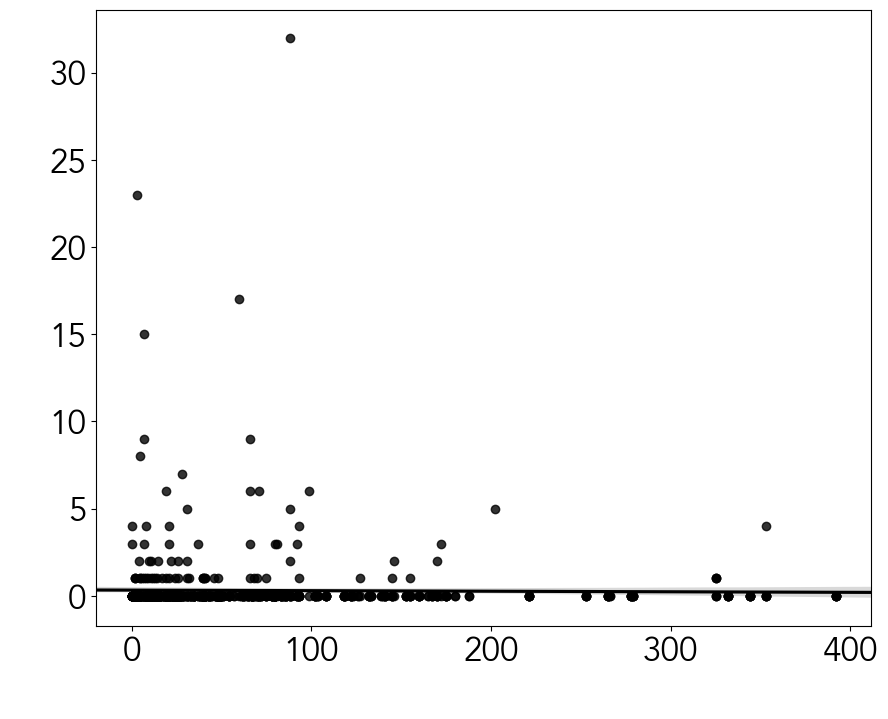

In [292]:
plt.rcParams['font.sans-serif'] = ['Avenir']
#plt.style.use('default')
plt.figure(figsize=(10,8))

plt.rcParams.update({'font.size': 24})

sns.regplot(
    data=wm_sc_combined, x="total_flies", y="total_scm_larvae",
    scatter=True, truncate=False, order=1, color="black",
)

plt.xlabel(' ')
plt.ylabel(' ')
plt.show()

In [294]:
# Pearson statistic for adult seed maggot complex vs. larvae.

stats.pearsonr(wm_sc_combined['total_flies'], wm_sc_combined['total_scm_larvae'])

PearsonRResult(statistic=-0.014273424725141131, pvalue=0.6763099987078718)